<a href="https://colab.research.google.com/github/Atharv-1905/Machine-Learning/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Random Forest**

**Significance of Random Forst**

1. Dimensionality Reduction (Cleaning the Junk)
2. Business Insights (The "Why")
     Example: Churn Prediction (Will a customer leave? & Why?)


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score



In [2]:
# 1. Load Data
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:

# 2. Train Model
# n_estimators=100: Create 100 trees
# oob_score=True: Use the leftover (Out-of-Bag) data to validate accuracy internally
rf_model = RandomForestClassifier(n_estimators=100,
                                  random_state=42,
                                  oob_score=True)

rf_model.fit(X_train, y_train)



RandomForestClassifier(oob_score=True, random_state=42)

**Random Forest Hyperparameters Cheat Sheet**


**1. n_estimators (Forest Level)**

    What it is: The total number of decision trees in the forest.

-How it works: More trees generally mean more robust predictions and less overfitting, as the errors cancel each other out.

-Trade-off: Higher numbers improve stability but increase training time and memory usage.


**2. max_features (Forest Level)**

    What it is: The size of the random subset of features to consider when looking for the best split at each node.

-How it works: It forces trees to be different (decorrelation).

1)"sqrt": Default for classification.

2)"log2": Takes the log base 2 of the feature count.

3)None: Considers all features (equivalent to Bagging).

-Trade-off: Smaller values reduce overfitting (lower variance) but might increase bias.

**3. max_depth (Tree Level)**

    What it is: The maximum height (number of levels) allowed for each individual tree.

-How it works:

1)None: Trees grow until all leaves are pure (can lead to massive, complex trees).

2)Integer (e.g., 10): Stops the tree from growing too deep.

-Trade-off: limiting depth creates simpler models and prevents the model from memorizing noise (overfitting).

**4. min_samples_split (Tree Level)**

    What it is: The minimum number of samples a node must have before it can be split.

-How it works: If a node has fewer samples than this number (e.g., 5), it will become a leaf node and stop growing.

-Trade-off: Higher values prevent the model from learning overly specific rules for tiny groups of data.

**5. min_samples_leaf (Tree Level)**

    What it is: The minimum number of samples required to be at a leaf node (the final answer bucket).

-How it works: Ensures that every decision is based on a sufficient amount of evidence.

-Trade-off: Higher values smooth the model boundaries (reduce variance); lower values allow the model to capture finer details.

**6. bootstrap (Forest Level)**

    What it is: Whether to use bootstrap samples (sampling with replacement) when building trees.

-How it works:

1)True (Default): Each tree sees a slightly different version of the dataset.

2)False: Every tree sees the exact same full dataset.

**7. oob_score (Validation)**

    What it is: Whether to use the "Out-of-Bag" (leftover) samples to estimate the generalization accuracy.

-How it works: Since roughly 1/3 of the data is not used for each tree during bootstrapping, these "unseen" rows act as a built-in validation set.

In [4]:
# 3. Evaluate
y_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"OOB Score: {rf_model.oob_score_:.2%}")



Accuracy: 100.00%
OOB Score: 91.67%


In [5]:
# 4. Feature Importance (The "Why")
# Since we have 100 trees, we can't draw them all.
# Instead, we look at which features were most useful on average.
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': iris.feature_names, 'Importance': importances})
print("\n--- Feature Importance ---")
print(feature_df.sort_values(by='Importance', ascending=False))


--- Feature Importance ---
             Feature  Importance
2  petal length (cm)    0.439994
3   petal width (cm)    0.421522
0  sepal length (cm)    0.108098
1   sepal width (cm)    0.030387


Feature Ranking (MDI Math):
1. flavanoids: 0.1945
2. color_intensity: 0.1730
3. alcohol: 0.1416
4. proline: 0.1370
5. od280/od315_of_diluted_wines: 0.1118
6. hue: 0.0769
7. total_phenols: 0.0351
8. malic_acid: 0.0331
9. alcalinity_of_ash: 0.0299
10. magnesium: 0.0259
11. proanthocyanins: 0.0184
12. ash: 0.0155
13. nonflavanoid_phenols: 0.0073


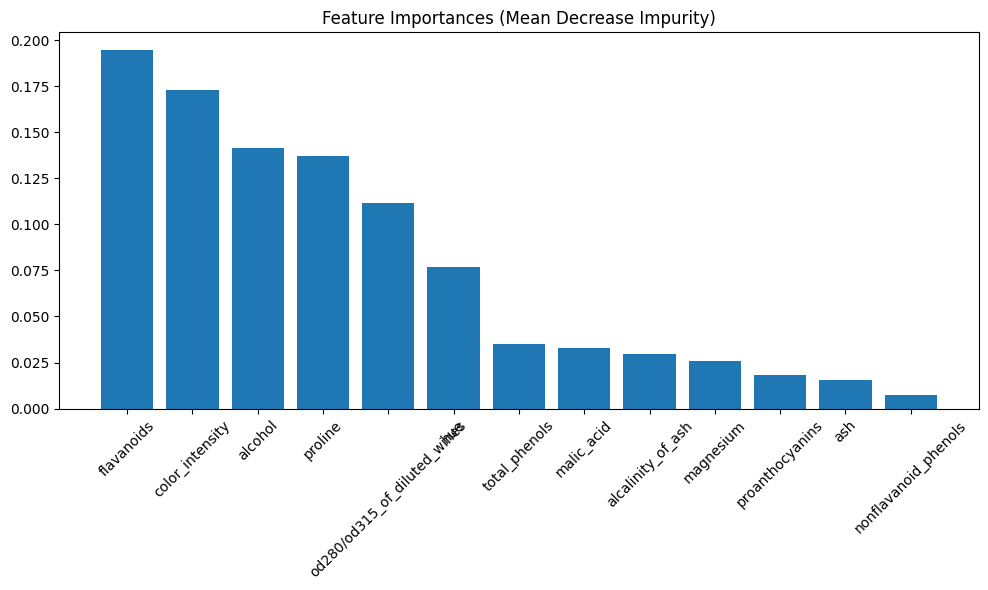

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# 1. Load Data
data = load_wine()
X, y = data.data, data.target

# 2. Random Forest Hyperparameters
# max_features='sqrt' implements the m = sqrt(p) math rule we discussed
# n_estimators=100 controls 'B' in the variance formula
rf = RandomForestClassifier(n_estimators=100,
                            max_features='sqrt',
                            criterion='gini',
                            random_state=42)

rf.fit(X, y)

# 3. Extracting Feature Importance (The MDI Math)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1] # Sort high to low

print("Feature Ranking (MDI Math):")
for f in range(X.shape[1]):
    print(f"{f+1}. {data.feature_names[indices[f]]}: {importances[indices[f]]:.4f}")

# 4. Visualizing Importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Mean Decrease Impurity)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [data.feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 1. Define the Model
rf = RandomForestClassifier(random_state=42)

# 2. Define the Search Space (The Hyperparameters)
param_dist = {
    'n_estimators': randint(100, 500),        # Forest: Try between 100 and 500 trees
    'max_features': ['sqrt', 'log2'],         # Forest: Randomness rule
    'max_depth': [None, 10, 20, 30],          # Tree: Depth limit
    'min_samples_leaf': randint(1, 10),       # Tree: Leaf size
    'bootstrap': [True, False]                # Forest: Sampling
}

# 3. Search
search = RandomizedSearchCV(rf,
                            param_distributions=param_dist,
                            n_iter=20,
                            cv=3,
                            random_state=42,
                            n_jobs=-1) # n_jobs=-1 uses all CPU cores!

search.fit(X_train, y_train)

print(f"Best Params: {search.best_params_}")
print(f"Best Accuracy: {search.best_score_:.2%}")

Best Params: {'bootstrap': True, 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 3, 'n_estimators': 314}
Best Accuracy: 95.83%


**Pro Tip for Project:** Always set n_jobs=-1. Random Forest is "embarrassingly parallel"—it can build 8 trees at once on an 8-core computer, making it 8x faster.